[*********************100%***********************]  38 of 39 completed


Loaded 730 trading days across 39 tickers.

=================== RUNNING DYNAMIC KALMAN + OU BACKTEST (113 PAIRS) ===================

--- DYNAMIC KALMAN + OU BACKTEST RESULTS ---
               Pair Final Beta (Kalman) OU Half-Life (Days) Initial Capital Final Capital Net Profit ($) Return (%)  Total Trades Win Rate (%) Max Drawdown (%)
  LTC-USD / XLM-USD             22.2023               2.2 d     $100,000.00   $121,259.69     $21,259.69     21.26%             2      100.00%            0.00%
  ALGO-USD / AR-USD              0.0186               0.5 d     $100,000.00   $102,367.93      $2,367.93      2.37%             3      100.00%            0.00%
  AR-USD / NEAR-USD              0.7654               0.6 d     $100,000.00   $102,285.27      $2,285.27      2.29%             3      100.00%            0.00%
ALGO-USD / NEAR-USD              0.0157               0.5 d     $100,000.00   $102,185.38      $2,185.38      2.19%             3      100.00%            0.00%
   AR-USD / DOT-USD  

/var/folders/x2/y_5_4b2x2l19y4g8jrvhjn3c0000gn/T/ipykernel_19325/2085031464.py:381: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


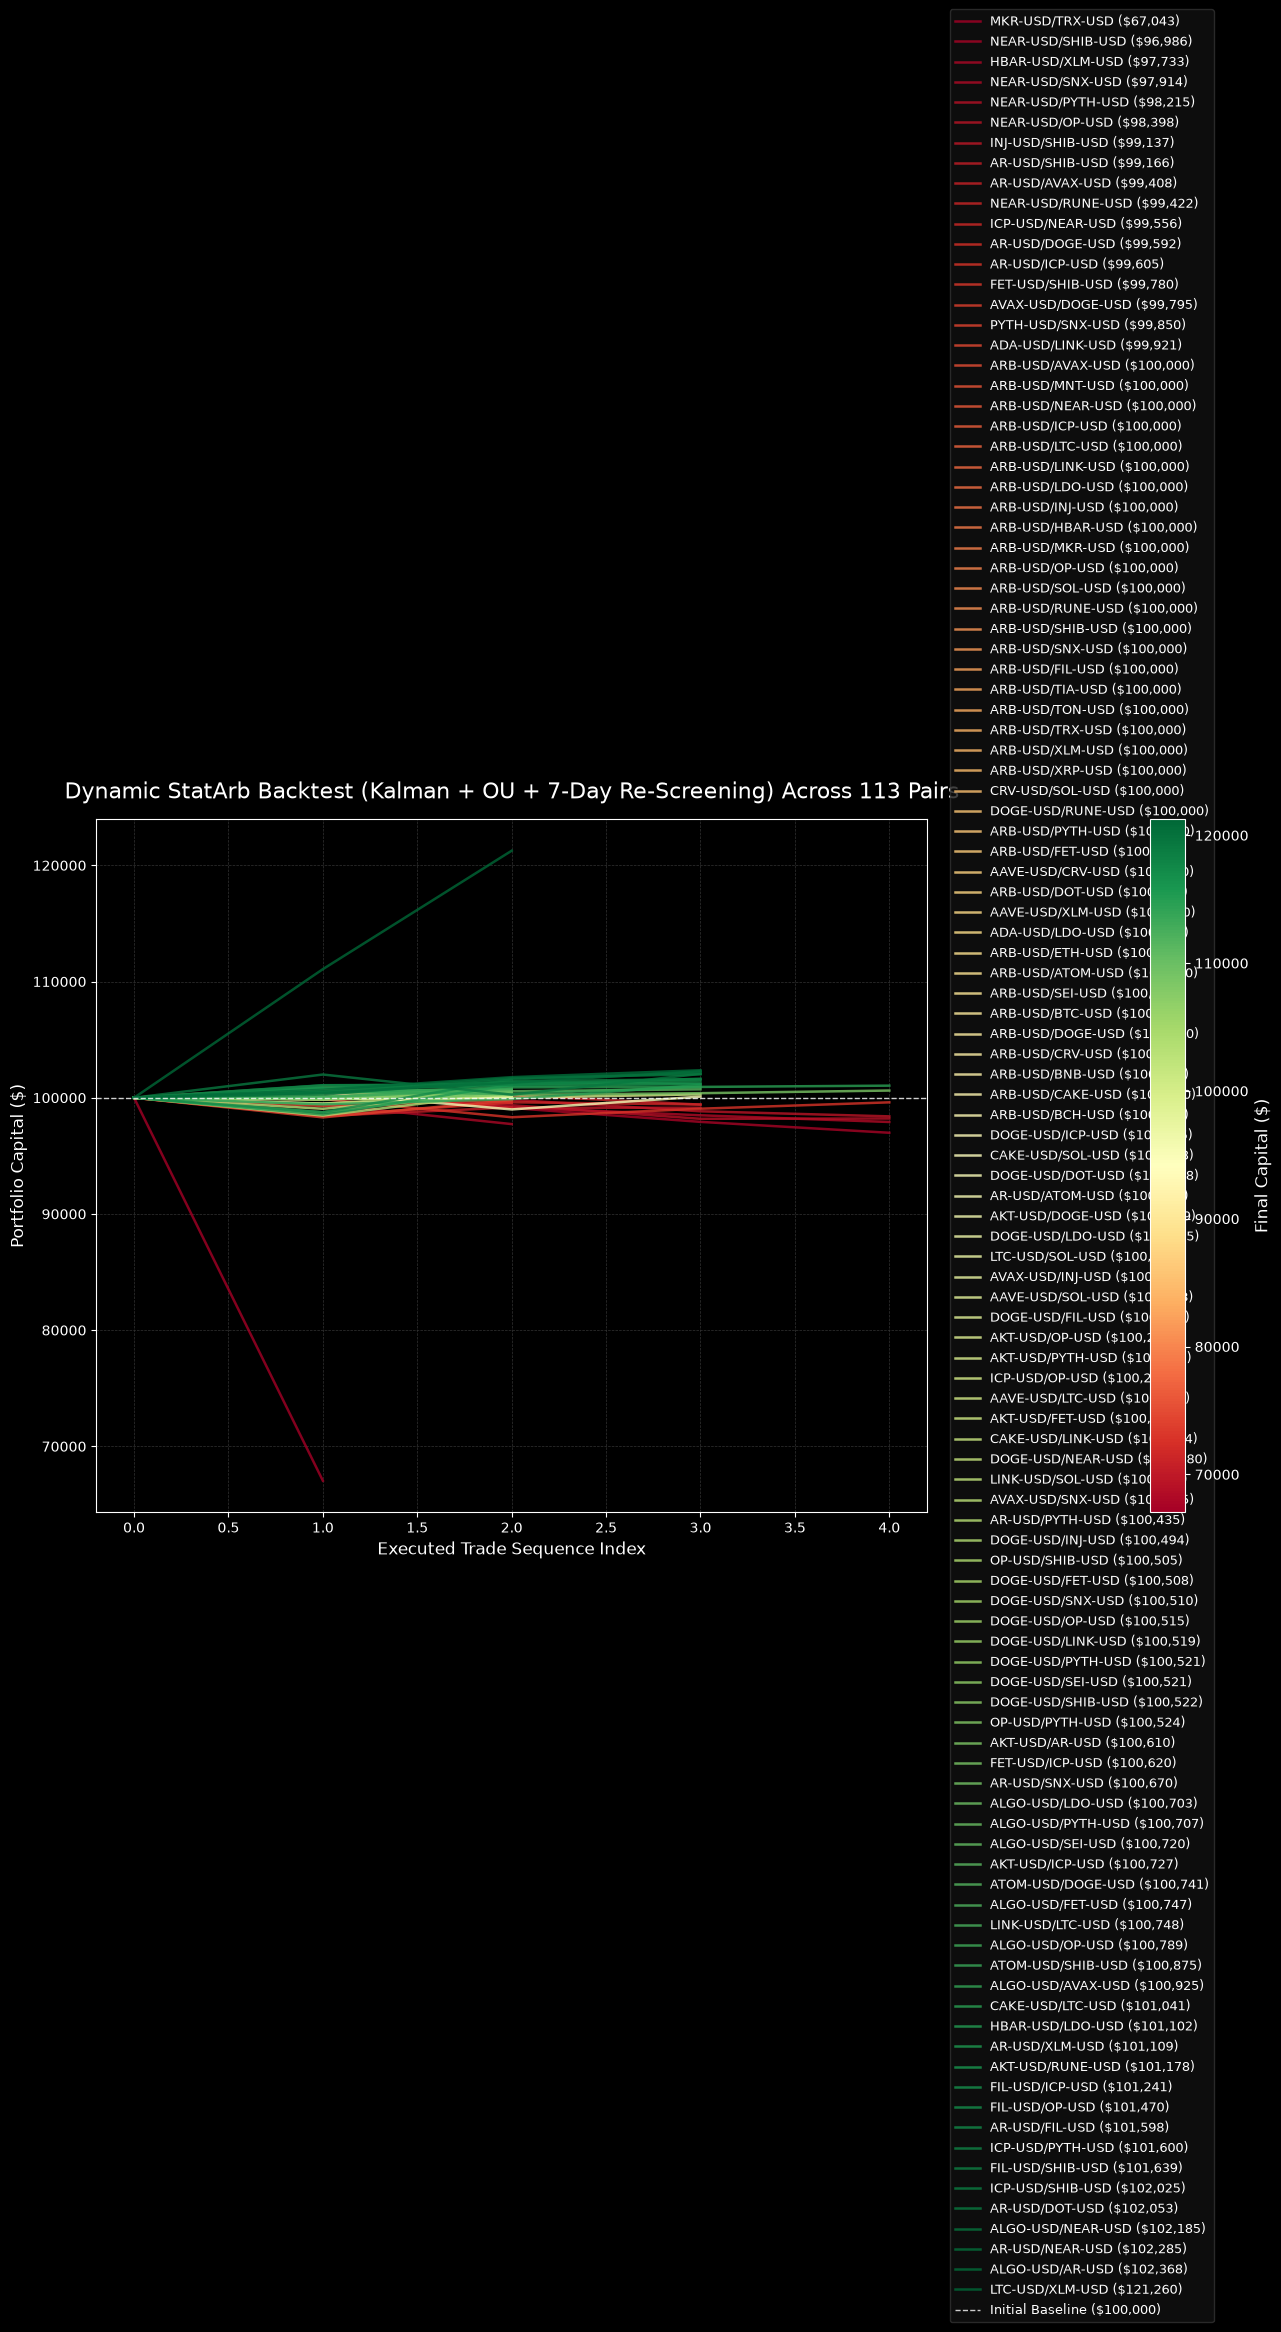

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import yfinance as yf

plt.style.use('dark_background')

# =====================================================================
# 1. FETCH HISTORICAL PRICE DATA
# =====================================================================
# tickers = [
#     'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'ORCL', 'CSCO', 'IBM',
#     'NVDA', 'AMD', 'AVGO', 'QCOM', 'INTC', 'TXN', 'MU', 'AMAT',
#     'LRCX', 'ADI', 'KLAC', 'TSM'
# ]

# tickers = [
#     # --- Semiconductor Ecosystem & Electronics Manufacturing ---
#     "MOSCHIP.NS",     # MosChip Technologies (Chip Design & Embedded Services)
#     "CGPOWER.NS",     # CG Power & Industrial Solutions (OSAT Plant Developer)
#     "DIXON.NS",       # Dixon Technologies (Electronic Manufacturing Services)
#     "TATAELXSI.NS",   # Tata Elxsi (Embedded & Semiconductor Design Engineering)
#     "BEL.NS",         # Bharat Electronics (Defense Electronics & Microelectronics)
#     "VEDL.NS",        # Vedanta (Proposed Semiconductor Fabrication/Fab Facility)
#     "POWERINDIA.NS",  # Hitachi Energy India (High-Voltage Power Infra for Fabs)
    
#     # --- Major Tech & IT Services ---
#     "TCS.NS",         # Tata Consultancy Services
#     "INFY.NS",        # Infosys
#     "HCLTECH.NS",     # HCL Technologies (VLSI & Chip Design services)
#     "WIPRO.NS",       # Wipro
#     "TECHM.NS",       # Tech Mahindra
#     "PERSISTENT.NS",  # Persistent Systems
#     "COFORGE.NS",     # Coforge
# ]

tickers = [
    # --- Mega-Caps & Store of Value ---
    'BTC-USD',   # Bitcoin
    'ETH-USD',   # Ethereum
    'LTC-USD',   # Litecoin
    'BCH-USD',   # Bitcoin Cash
    
    # --- Major Layer-1 & Smart Contract Platforms ---
    'SOL-USD',   # Solana
    'BNB-USD',   # BNB
    'ADA-USD',   # Cardano
    'AVAX-USD',  # Avalanche
    'NEAR-USD',  # NEAR Protocol
    'DOT-USD',   # Polkadot
    'ATOM-USD',  # Cosmos
    'TRX-USD',   # TRON
    'TON-USD',   # Toncoin
    'SEI-USD',   # Sei
    'ICP-USD',   # Internet Computer
    'ALGO-USD',  # Algorand
    'HBAR-USD',  # Hedera
    
    # --- Layer-2 & Scaling Solutions ---
    'ARB-USD',   # Arbitrum
    'OP-USD',    # Optimism
    'MNT-USD',   # Mantle
    
    # --- Decentralized Finance (DeFi) & Exchanges ---
    'AAVE-USD',  # Aave
    'MKR-USD',   # Maker
    'CRV-USD',   # Curve DAO
    'LDO-USD',   # Lido DAO
    'SNX-USD',   # Synthetix
    'INJ-USD',   # Injective
    'RUNE-USD',  # THORChain
    'CAKE-USD',  # PancakeSwap
    
    # --- Oracle, Storage & Infrastructure ---
    'LINK-USD',  # Chainlink
    'FIL-USD',   # Filecoin
    'TIA-USD',   # Celestia
    'AR-USD',    # Arweave
    'PYTH-USD',  # Pyth Network
    
    # --- AI, Big Data & DePIN ---
    'FET-USD',   # Artificial Superintelligence Alliance
    'AKT-USD',   # Akash Network
    
    # --- Payment & High-Volume Altcoins ---
    'XRP-USD',   # XRP
    'XLM-USD',   # Stellar
    'DOGE-USD',  # Dogecoin
    'SHIB-USD',  # Shiba Inu
]

print(f"Downloading historical data for {len(tickers)} tickers...")
# Fetch in 720-day chunks to respect Yahoo Finance's 730-day limit for 1h bars
# d1 = yf.download(tickers, start="2022-10-04", end="2024-10-03", interval="1h", auto_adjust=False)
# d2 = yf.download(tickers, start="2024-10-04", interval="1h", auto_adjust=False)

# # Combine and remove duplicate timestamps at the seam
# df_raw = pd.concat([d1, d2])
# df_raw = df_raw[~df_raw.index.duplicated(keep='first')].sort_index()

# print(f"Combined dataset: {df_raw.shape[0]} total hourly bars loaded.")

df_raw = yf.download(tickers, start="2024-10-04", auto_adjust=False)

if 'Adj Close' in df_raw.columns:
    df_prices = df_raw['Adj Close'].dropna(how='all')
elif 'Close' in df_raw.columns:
    df_prices = df_raw['Close'].dropna(how='all')
else:
    df_prices = df_raw.xs('Adj Close', axis=1, level=0).dropna(how='all')

df_prices = df_prices.ffill().bfill()
print(f"Loaded {df_prices.shape[0]} trading days across {df_prices.shape[1]} tickers.")

# 80/20 Chronological Split
split_idx = int(len(df_prices) * 0.80)
train_df = df_prices.iloc[:split_idx]
test_df = df_prices.iloc[split_idx:]

# Load pairs from screening or summary
def extract_candidate_pairs(df_train):
    n = df_train.shape[1]
    keys = df_train.columns
    pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            s1, s2 = df_train[keys[i]], df_train[keys[j]]
            _, pval, _ = coint(s1, s2)
            pairs.append((keys[i], keys[j], pval))
    return pd.DataFrame(pairs, columns=['Stock_1', 'Stock_2', 'p_value'])

candidate_pairs = extract_candidate_pairs(train_df)
target_pairs = candidate_pairs[candidate_pairs['p_value'] < 0.05].copy()
if len(target_pairs) == 0:
    target_pairs = candidate_pairs.sort_values(by='p_value').head(10).copy()

# =====================================================================
# 2. KALMAN FILTER IMPLEMENTATION FOR DYNAMIC BETA & ALPHA
# =====================================================================
class KalmanFilterHedgeRatio:
    """
    Online state-space Kalman Filter updating beta and alpha dynamically:
    Observation: y_t = alpha_t + beta_t * x_t + v_t, v_t ~ N(0, V_w)
    State: theta_t = theta_{t-1} + w_t,             w_t ~ N(0, V_w)
    """
    def __init__(self, delta=1e-4, R=1e-3):
        self.delta = delta
        self.R = R
        self.Vw = (self.delta / (1 - self.delta)) * np.eye(2)
        self.Ve = self.R
        self.theta = np.zeros(2) # [alpha, beta]
        self.P = np.zeros((2, 2))

    def update(self, x, y):
        # State estimation prior
        P_prior = self.P + self.Vw
        
        # Measurement matrix
        H = np.array([1.0, x])
        
        # Measurement error variance
        y_hat = np.dot(H, self.theta)
        error = y - y_hat
        Qt = np.dot(H, np.dot(P_prior, H.T)) + self.Ve
        
        # Kalman Gain
        K = np.dot(P_prior, H.T) / Qt
        
        # State update
        self.theta = self.theta + K * error
        self.P = P_prior - np.outer(K, np.dot(H, P_prior))
        
        alpha, beta = self.theta[0], self.theta[1]
        return alpha, beta, error

# =====================================================================
# 3. ORNSTEIN-UHLENBECK (OU) PROCESS PARAMETER ESTIMATOR
# =====================================================================
def estimate_ou_parameters(spread_series):
    """
    Fits OU process dS_t = theta*(mu - S_t)*dt + sigma*dW_t
    via discrete AR(1) regression: S_t = a + b*S_{t-1} + e_t
    """
    if len(spread_series) < 30:
        return np.nan, np.nan, np.nan
        
    s_lag = spread_series.shift(1).dropna()
    s_curr = spread_series.iloc[1:]
    
    X = sm.add_constant(s_lag)
    model = sm.OLS(s_curr, X).fit()
    
    a, b = model.params.iloc[0], model.params.iloc[1]
    
    if b >= 1.0 or b <= 0.0:
        return np.nan, np.nan, np.nan
        
    theta = -np.log(b)
    mu = a / (1.0 - b)
    half_life = np.log(2.0) / theta
    return half_life, mu, theta

# =====================================================================
# 4. DYNAMIC BACKTEST ENGINE WITH 7-DAY RE-SCREENING
# =====================================================================
class DynamicStatArbEngine:
    def __init__(self, initial_capital=100000.0, z_entry=2.0, z_exit=0.0, z_stop=3.5):
        self.initial_capital = initial_capital
        self.z_entry = z_entry
        self.z_exit = z_exit
        self.z_stop = z_stop

    def run_pair(self, s1_series, s2_series, lookback_window=252, rescreen_days=7):
        kf = KalmanFilterHedgeRatio()
        capital = self.initial_capital
        equity_curve = [capital]
        trades = []
        
        in_pos = False
        pos_type = None
        entry_p1, entry_p2 = 0.0, 0.0
        u1, u2 = 0.0, 0.0
        
        spread_history = []
        is_cointegrated = True
        current_half_life = np.nan
        
        # Warm up Kalman filter on initial window
        for k in range(min(60, len(s1_series))):
            kf.update(s2_series.iloc[k], s1_series.iloc[k])
            
        for i in range(60, len(s1_series)):
            p1 = s1_series.iloc[i]
            p2 = s2_series.iloc[i]
            
            # 1. Update Kalman Filter state
            alpha_t, beta_t, err_t = kf.update(p2, p1)
            spread_t = p1 - (beta_t * p2 + alpha_t)
            spread_history.append(spread_t)
            
            # 2. 7-Day Rolling Cointegration Re-screening Circuit Breaker
            if i % rescreen_days == 0 and i >= lookback_window:
                s1_win = s1_series.iloc[i - lookback_window : i]
                s2_win = s2_series.iloc[i - lookback_window : i]
                _, pval, _ = coint(s1_win, s2_win)
                is_cointegrated = (pval < 0.05)
                
            # 3. OU Process & Dynamic Z-Score Calculation
            if len(spread_history) >= 60:
                recent_spreads = pd.Series(spread_history[-60:])
                hl, mu, _ = estimate_ou_parameters(recent_spreads)
                current_half_life = hl if not np.isnan(hl) else current_half_life
                
                std_spread = recent_spreads.std()
                z_t = (spread_t - recent_spreads.mean()) / std_spread if std_spread > 0 else 0.0
            else:
                z_t = 0.0
                
            # 4. Execution Logic with Circuit Breaker
            if not in_pos:
                if is_cointegrated and abs(z_t) >= self.z_entry:
                    pos_type = 'LONG_SPREAD' if z_t <= -self.z_entry else 'SHORT_SPREAD'
                    in_pos = True
                    alloc = capital * 0.15
                    u1 = (alloc / 2.0) / p1
                    u2 = ((alloc / 2.0) * beta_t) / p2
                    entry_p1, entry_p2 = p1, p2

            elif in_pos:
                tp = (pos_type == 'LONG_SPREAD' and z_t >= self.z_exit) or \
                     (pos_type == 'SHORT_SPREAD' and z_t <= self.z_exit)
                sl = (abs(z_t) >= self.z_stop) or (not is_cointegrated)
                
                if tp or sl:
                    if pos_type == 'LONG_SPREAD':
                        pnl = (u1 * (p1 - entry_p1)) + (u2 * (entry_p2 - p2))
                    else:
                        pnl = (u1 * (entry_p1 - p1)) + (u2 * (p2 - entry_p2))
                        
                    capital += pnl
                    equity_curve.append(capital)
                    trades.append({'pnl': pnl, 'type': pos_type, 'reason': 'Coint_Break' if not is_cointegrated else ('SL' if sl else 'TP'), 'capital': capital})
                    in_pos = False

        return pd.DataFrame(trades), np.array(equity_curve), current_half_life, beta_t

# =====================================================================
# 5. RUN DYNAMIC BACKTEST ACROSS ALL PAIRS
# =====================================================================
engine = DynamicStatArbEngine(initial_capital=100000.0)

results_list = []
all_equity_curves = []
pair_labels = []

print(f"\n=================== RUNNING DYNAMIC KALMAN + OU BACKTEST ({len(target_pairs)} PAIRS) ===================")

for idx, row in target_pairs.iterrows():
    s1_name, s2_name = row['Stock_1'], row['Stock_2']
    
    test_s1, test_s2 = test_df[s1_name], test_df[s2_name]
    trades_df, equity, final_hl, final_beta = engine.run_pair(test_s1, test_s2)
    
    all_equity_curves.append(equity)
    pair_labels.append(f"{s1_name}/{s2_name}")
    
    final_cap = equity[-1]
    net_pnl = final_cap - 100000.0
    ret_pct = (net_pnl / 100000.0) * 100.0
    n_trades = len(trades_df)
    win_rate = (trades_df['pnl'] > 0).mean() * 100.0 if n_trades > 0 else 0.0
    
    peak = np.maximum.accumulate(equity)
    max_dd = ((equity - peak) / peak).min() * 100.0 if len(equity) > 1 else 0.0
    
    results_list.append({
        'Pair': f"{s1_name} / {s2_name}",
        'Final Beta (Kalman)': final_beta,
        'OU Half-Life (Days)': final_hl,
        'Initial Capital': 100000.0,
        'Final Capital': final_cap,
        'Net Profit ($)': net_pnl,
        'Return (%)': ret_pct,
        'Total Trades': n_trades,
        'Win Rate (%)': win_rate,
        'Max Drawdown (%)': max_dd
    })

df_dynamic_stats = pd.DataFrame(results_list).sort_values(by='Net Profit ($)', ascending=False)

print("\n--- DYNAMIC KALMAN + OU BACKTEST RESULTS ---")
print(df_dynamic_stats.to_string(index=False, formatters={
    'Final Beta (Kalman)': '{:.4f}'.format,
    'OU Half-Life (Days)': lambda x: f"{x:.1f} d" if not np.isnan(x) else "N/A",
    'Initial Capital': '${:,.2f}'.format,
    'Final Capital': '${:,.2f}'.format,
    'Net Profit ($)': '${:,.2f}'.format,
    'Return (%)': '{:.2f}%'.format,
    'Win Rate (%)': '{:.2f}%'.format,
    'Max Drawdown (%)': '{:.2f}%'.format
}))

# =====================================================================
# 6. ALL-IN-ONE GRADIENT EQUITY VISUALIZATION
# =====================================================================
final_caps = [eq[-1] for eq in all_equity_curves]
sorted_order = np.argsort(final_caps)

fig, ax = plt.subplots(figsize=(16, 9), facecolor='black')
ax.set_facecolor('black')

cmap = plt.colormaps['RdYlGn']
num_pairs = len(all_equity_curves)

for rank, sim_idx in enumerate(sorted_order):
    color_val = rank / max(1, (num_pairs - 1))
    eq = all_equity_curves[sim_idx]
    label_text = f"{pair_labels[sim_idx]} (${eq[-1]:,.0f})"
    
    ax.plot(eq, color=cmap(color_val), alpha=0.8, linewidth=1.8, label=label_text)

ax.set_title(f"Dynamic StatArb Backtest (Kalman + OU + 7-Day Re-Screening) Across {num_pairs} Pairs", fontsize=16, color='white', pad=15)
ax.set_xlabel("Executed Trade Sequence Index", fontsize=12, color='white')
ax.set_ylabel("Portfolio Capital ($)", fontsize=12, color='white')

ax.axhline(100000, color='white', linestyle='--', linewidth=1, alpha=0.8, label="Initial Baseline ($100,000)")
ax.grid(True, color='#333333', linestyle='--', linewidth=0.5)

ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=True, facecolor='#111111', edgecolor='#333333')

min_c, max_c = min(final_caps), max(final_caps)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min_c, vmax=max_c))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.18)
cbar.set_label("Final Capital ($)", color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax, 'yticklabels'), color='white')

plt.tight_layout()
plt.show()

In [25]:
df_dynamic_stats.to_csv("dynamic_statistical_arbitrage_summary_crypto.csv", index=False)